## Модели классификации для нескольких классов

Ирисы Фишера - самый популярный в статистической литературе набор данных, часто используемый для иллюстрации работы различных алгоритмов классификации.

Выборка состоит из 150 экземпляров ирисов трех видов, для которых измерялись четыре характеристики: длина и ширина чашелистика (Sepal.Length и Sepal.Width), длина и ширина лепестка (Petal.Length и Petal.Width). Требуется на основе этого набора данных, построить различные модели многоклассовой классификации, оценивающие каждый из трех видов растения по данным проведенных измерений.

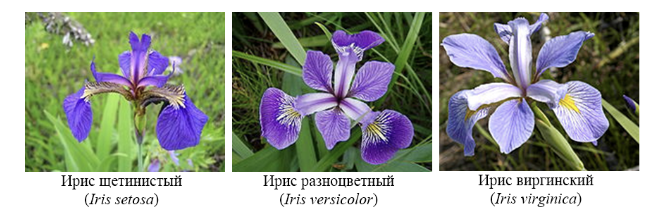

Импортируем необходимые библиотеки:

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

Библиотека Scikit-Learn предоставляет чистые датасеты, которые вы можете использовать при построении моделей машинного обучения. Они поставляются вместе с Scikit-Learn (https://scikit-learn.ru/7-1-toy-datasets/).

Набор данных Iris, классический набор данных в машинном обучении и статистике. Он входит в модуль datasets библиотеки scikit-learn и загрузить его можно, вызвав функцию load_iris().

In [98]:
from sklearn.datasets import load_iris
iris = load_iris()

In [99]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [100]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [101]:
print(iris.data[:10])

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]]


In [102]:
print(iris.target_names)
print(iris.target)

['setosa' 'versicolor' 'virginica']
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


Набор данных состоит из длины/ширины двух типов лепестков Ириса: sepal и petal.

Целевая переменная — это сорт Ириса: 0 — Setosa, 1 — Versicolor, 2 — Virginica. 

Соответственно, наша задача — по имеющимся данным попробовать найти зависимости между размерами лепестков и сортами Ирисов.

In [103]:
type(iris)

sklearn.utils._bunch.Bunch

Объект Bunch — это словарь, который предоставляет свои ключи как атрибуты.

Формируем DataFrame:

In [104]:
iris_df = pd.DataFrame(iris.data)

In [105]:
iris_df.head()

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [106]:
# Делаем имена колонок такие же, как имена переменных:
iris_df.columns = iris.feature_names
# Добавляем столбец с целевой переменной: 
iris_df['target'] = iris.target
# Для наглядности добавляем столбец с сортами: 
iris_df['name'] = iris_df.target.apply(lambda x : iris.target_names[x])
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [107]:
iris_df.shape

(150, 6)

In [108]:
# информация о наборе данных
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   name               150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [109]:
iris_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [110]:
iris_df['target'].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

In [111]:
iris_df['name'].value_counts()

name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

### Описательная статистика

In [112]:
iris_df.hist(figsize = (15,10), bins = 50);

In [113]:
sns.pairplot(iris_df[['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)','name']], hue = 'name')

Видно, что «petal width (cm)» и «petal length (cm)» имеют сильную зависимость — точки вытянуты вдоль одной линии. И в принципе по этим же признакам можно строить классификацию, т.к. точки по цвету сгруппированы достаточно компактно. А вот, например, с помощью переменных «sepal width (cm)» и «sepal length (cm)» качественную классификацию не построить, т.к. точки, относящиеся к сортам Versicolor и Virginica, перемешаны между собой.

In [114]:
sns.scatterplot(data=iris_df, x="sepal length (cm)", y="sepal width (cm)", hue="name")

<Axes: xlabel='petal width (cm)', ylabel='Density'>

In [115]:
corr = iris_df[['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']].corr()
corr

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.117570,0.871754,0.817941
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126
petal length (cm),0.871754,-0.428440,1.000000,0.962865
petal width (cm),0.817941,-0.366126,0.962865,1.000000


In [116]:
sns.heatmap(corr, square=True, annot=True, linewidths=.5)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


<Axes: >

Действительно видим, что между переменными «petal length (cm)» и «petal width (cm)» выявлена очень сильная зависимость 0.96, а между «sepal width (cm)» и «sepal length (cm)» - слабая корреляция.

### Обучение классификатора

In [117]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(iris_df[['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']], 
                                                      iris_df['target'], 
                                                      test_size=0.3, 
                                                      random_state=19)

In [118]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=1)

In [119]:
# Обучаем модель на обучающей выборке
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

In [120]:
y_pred = knn.predict(X_test)
y_pred

array([0, 2, 1, 1, 0, 0, 0, 0, 1, 2, 1, 0, 1, 0, 2, 0, 2, 0, 1, 0, 1, 1,
       1, 1, 2, 1, 2, 2, 1, 2, 0, 1, 2, 1, 1, 0, 0, 0, 2, 2, 1, 2, 1, 2,
       2])

In [121]:
# Другой способ для вычисления метрики
from sklearn.metrics import accuracy_score
basic_accuracy=accuracy_score(y_test, y_pred)
basic_accuracy

0.9333333333333333

In [122]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.88      0.94      0.91        16
           2       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.94        45
weighted avg       0.93      0.93      0.93        45



### Confusion Matrix

In [123]:
from sklearn.metrics import confusion_matrix

In [124]:
conf_matrix = confusion_matrix(y_test, y_pred)

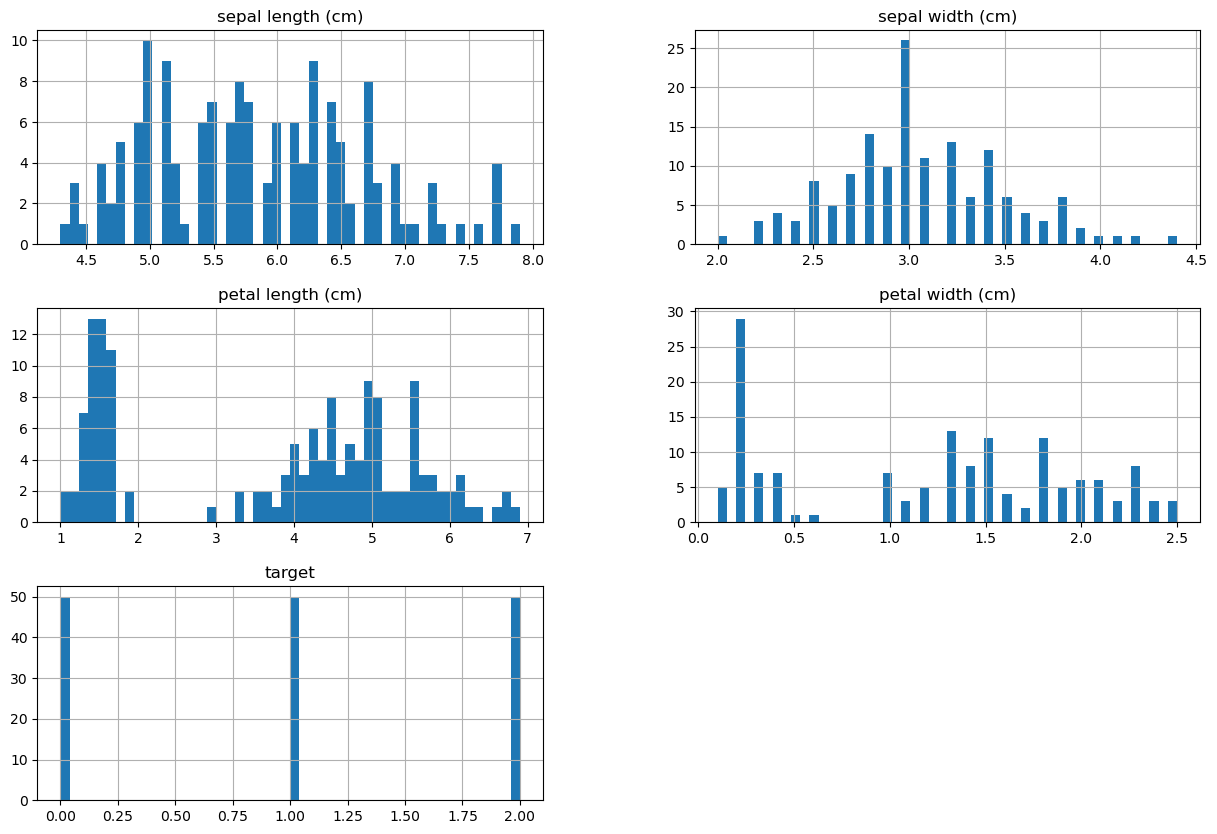

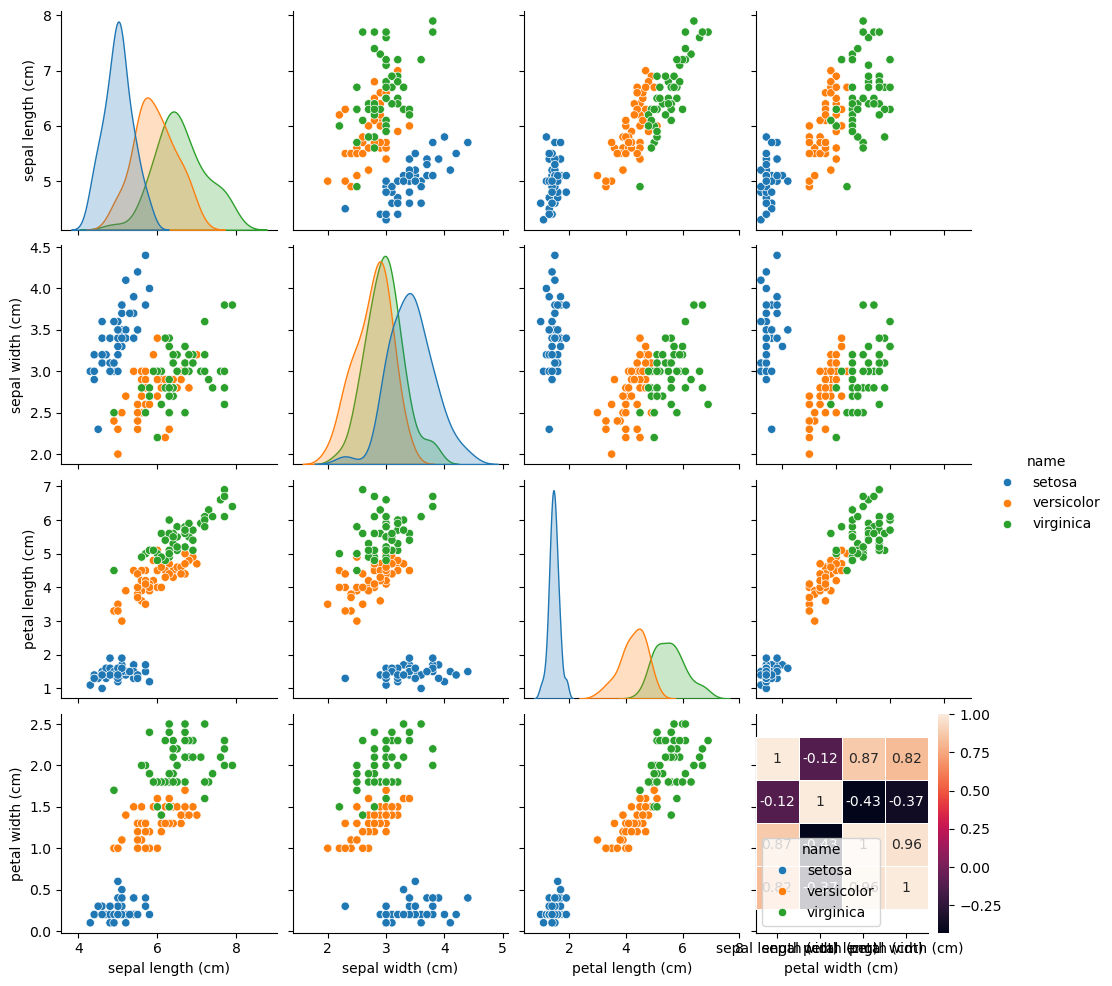

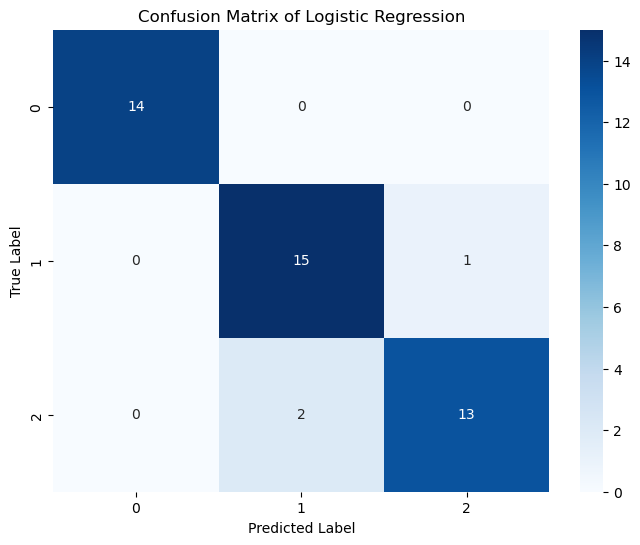

In [125]:
Y = iris_df['target']
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(Y), yticklabels=np.unique(Y))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix of Logistic Regression')
plt.show()

### Метрики многоклассовой классификации

1) Микро-усреднение (micro-averaging) является эквивалентом accuracy и подходит __при сбалансированных классах__. Элементы consufion matrix усредняются между бинарными прогнозами для каждого класса, после чего метрики рассчитываются на полученной матрице. На примере Precision и Recall это выглядит следующим образом:

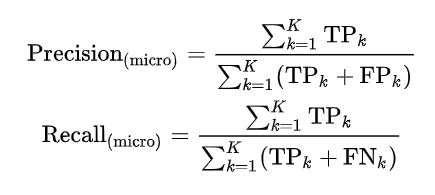

In [126]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [127]:
print(precision_score(y_test, y_pred, average='micro'))
print(recall_score(y_test, y_pred, average='micro'))
print(f1_score(y_test, y_pred, average='micro'))

0.9333333333333333
0.9333333333333333
0.9333333333333333


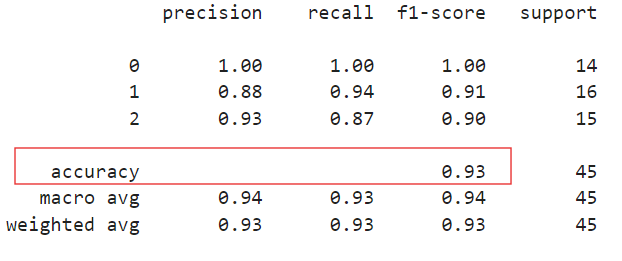

2) Макро-усреднение (macro-averaging) представляет собой среднее арифметическое подсчитанной метрики для каждого класса и используется __при дисбалансе классов, когда важен каждый класс__. В таком случае все классы учитываются равномерно независимо от их размера.

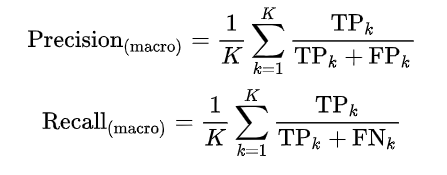

In [128]:
print(precision_score(y_test, y_pred, average='macro'))
print(recall_score(y_test, y_pred, average='macro'))
print(f1_score(y_test, y_pred, average='macro'))

0.9369747899159663
0.9347222222222222
0.9352142110762801


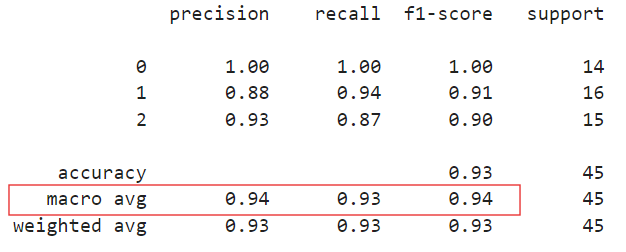

3) Взвешенное усреднение (weighted averaging) рассчитывается как взвешенное среднее и также применяется в случае __дисбаланса классов__, но только когда важность класса учитывается в зависимости от количества объектов с таким классом, то есть __когда важны наибольшие классы__. При таком подходе важность каждого класса учитывается с присвоением им весов. Вес класса w_k может устанавливаться по-разному, например, как доля примеров этого класса в обучающей выборке:

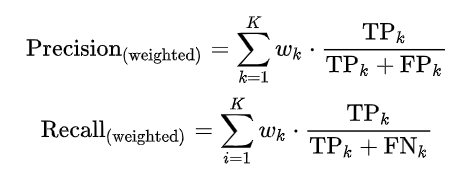

In [129]:
print(precision_score(y_test, y_pred, average='weighted'))
print(recall_score(y_test, y_pred, average='weighted'))
print(f1_score(y_test, y_pred, average='weighted'))

0.9343604108309991
0.9333333333333333
0.9331940090560781


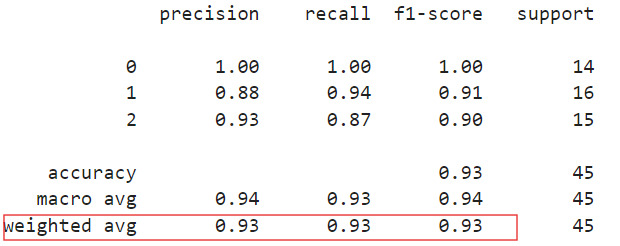

### Кроссвалидация

__Кросс-валидация (перекрестная проверка)__ — это метод оценки производительности модели машинного обучения, который позволяет более эффективно использовать данные для обучения и тестирования. Вместо одного разделения на обучающую и тестовую выборки, мы делаем несколько таких разделений и усредняем результаты.

##### Как работает кросс-валидация

Один из самых распространенных методов — k-блочная кросс-валидация (k-fold cross-validation).

Шаги k-блочной кросс-валидации:
- __Разбиение данных:__ Исходный набор данных случайным образом разбивается на k частей (фолдов) примерно одинакового размера. Обычно k выбирают 5 или 10.

- __Обучение и валидация:__ Модель обучается k раз. Каждый раз:
1. Один из k фолдов используется в качестве тестовой выборки (валидационной).
2. Оставшиеся k-1 фолдов объединяются в обучающую выборку.
3. Модель обучается на обучающей выборке и оценивается на тестовой.
   
- __Сбор метрик:__ После каждого из k запусков вычисляется метрика качества (например, точность). В итоге получаем k значений метрики.

- __Усреднение:__  Вычисляется среднее значение и стандартное отклонение по k метрикам. Это дает итоговую оценку производительности модели.

##### Стратифицированная кросс-валидация
Для задач классификации часто используют стратифицированную кросс-валидацию. Она сохраняет распределение классов в каждом фолде таким же, как и в исходном наборе данных. Это особенно важно, если данные несбалансированы.

In [130]:
X = iris_df[['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']] 
                                                    

In [131]:
y = iris_df['target']

In [132]:
from sklearn.model_selection import cross_val_score, GridSearchCV, learning_curve

In [133]:
# Cross-validation
cv_scores = cross_val_score(knn, X, y, cv=5)
print('Cross-validation scores: ', cv_scores)
print('Mean cross-validation score: ', np.mean(cv_scores))

Cross-validation scores:  [0.96666667 0.96666667 0.93333333 0.93333333 1.        ]
Mean cross-validation score:  0.96


### Настройка гиперпараметров

__GridSearch (сеточный поиск)__ - это метод подбора оптимальных гиперпараметров модели машинного обучения путем полного перебора всех возможных комбинаций.

Как работает GridSearch?

- Задаем сетку гиперпараметров: для каждого гиперпараметра указываем список возможных значений.

- Создаем все возможные комбинации этих гиперпараметров.

- Для каждой комбинации:

1. Обучаем модель на обучающих данных.

2. Оцениваем модель с помощью кросс-валидации.

- Выбираем комбинацию, которая показала наилучший результат.

- Обучаем финальную модель на всем обучающем наборе с лучшими найденными гиперпараметрами.

In [134]:
param_grid = {'n_neighbors': [1,2,3,4,5]}

knn = KNeighborsClassifier()

grid_search = GridSearchCV(estimator=knn, param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)
print("Best Parameters: ", grid_search.best_params_)

Best Parameters:  {'n_neighbors': 3}


In [135]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [136]:
y_pred = knn.predict(X_test)
y_pred

array([0, 2, 1, 1, 0, 0, 0, 0, 1, 2, 1, 0, 1, 0, 2, 0, 2, 0, 1, 0, 1, 1,
       1, 1, 2, 1, 2, 2, 1, 2, 0, 1, 2, 1, 1, 0, 0, 0, 2, 2, 1, 2, 1, 2,
       2])

In [137]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.88      0.94      0.91        16
           2       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.94        45
weighted avg       0.93      0.93      0.93        45



In [138]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [139]:
y_pred = knn.predict(X_test)
y_pred

array([0, 2, 1, 1, 0, 0, 0, 0, 1, 2, 1, 0, 1, 0, 2, 0, 2, 0, 1, 0, 1, 1,
       1, 1, 2, 1, 2, 2, 1, 2, 0, 2, 2, 1, 1, 0, 0, 0, 2, 2, 1, 2, 1, 2,
       2])

In [140]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.94      0.94      0.94        16
           2       0.93      0.93      0.93        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



In [141]:
# Определяем сетку параметров для KNN
param_grid = {
    'n_neighbors': list(range(1, 31)),           # количество соседей от 1 до 30
    'weights': ['uniform', 'distance'],          # тип весов
    'metric': ['euclidean', 'manhattan', 'minkowski'],  # метрики расстояния
    'p': [1, 2, 3]                               # параметр для метрики Минковского
}

# Создаем GridSearchCV
grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5,                    # 5-фолдовая кросс-валидация
    scoring='accuracy',       # метрика для оптимизации
    n_jobs=-1,               # использовать все ядра
    verbose=1,               # вывод прогресса
    return_train_score=True  # возвращать оценки на обучении
)

# Запускаем поиск
print("Запуск GridSearch...")
grid_search.fit(X_train, y_train)

print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ GRIDSEARCH")
print("="*50)

Запуск GridSearch...
Fitting 5 folds for each of 540 candidates, totalling 2700 fits

РЕЗУЛЬТАТЫ GRIDSEARCH


In [142]:
print("Лучшие параметры:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"Лучшая точность (CV): {grid_search.best_score_:.4f}")



Лучшие параметры:
  metric: euclidean
  n_neighbors: 8
  p: 1
  weights: distance
Лучшая точность (CV): 0.9905


In [143]:
# Оценка на тестовых данных
best_knn = grid_search.best_estimator_
y_pred_best = best_knn.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred_best)
print(f"Точность на тестовых данных: {test_accuracy:.4f}")

print(f"Улучшение точности: {test_accuracy - basic_accuracy:.4f}")

Точность на тестовых данных: 0.9778
Улучшение точности: 0.0444


## Дерево решений

In [144]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

In [145]:
dt_classifier = DecisionTreeClassifier(
    max_depth=3,           # Ограничиваем глубину для избежания переобучения
    random_state=19,       # Для воспроизводимости результатов
    min_samples_split=5,   # Минимальное количество samples для разделения
    min_samples_leaf=2     # Минимальное количество samples в листе
)

In [146]:
dt_classifier.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=2, min_samples_split=5,
                       random_state=19)

In [147]:
y_pred_dt = dt_classifier.predict(X_test)
y_pred_proba_dt = dt_classifier.predict_proba(X_test)

In [148]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt, average='weighted')
recall_dt = recall_score(y_test, y_pred_dt, average='weighted')
f1_dt = f1_score(y_test, y_pred_dt, average='weighted')
roc_auc_dt = roc_auc_score(y_test, y_pred_proba_dt, multi_class='ovr')

In [149]:
print(f"accuracy {accuracy_dt:.2f}\n")
print(classification_report(y_test, y_pred_dt, 
                          target_names=['setosa', 'versicolor', 'virginica']))


accuracy 0.93

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        14
  versicolor       0.84      1.00      0.91        16
   virginica       1.00      0.80      0.89        15

    accuracy                           0.93        45
   macro avg       0.95      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45



In [150]:
plt.figure(figsize=(15, 5))

<Figure size 1500x500 with 0 Axes>

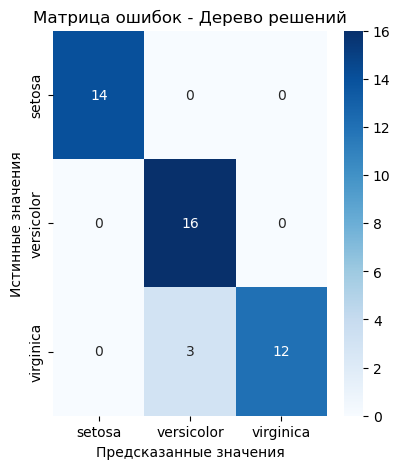

In [151]:
plt.subplot(1, 3, 1)
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['setosa', 'versicolor', 'virginica'],
            yticklabels=['setosa', 'versicolor', 'virginica'])
plt.title('Матрица ошибок - Дерево решений')
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.show()

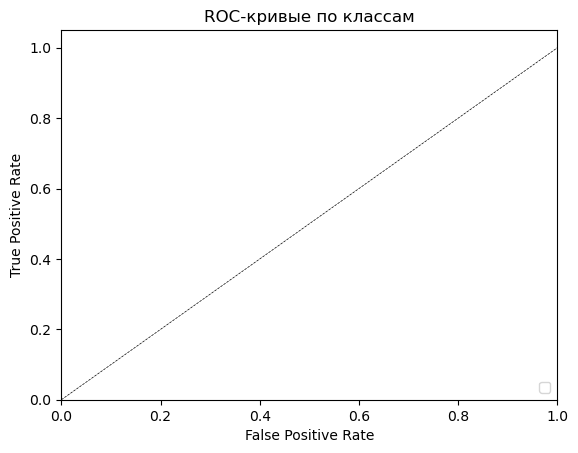

In [152]:
plt.plot([0, 1], [0, 1], 'k--', linewidth=0.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые по классам')
plt.legend(loc="lower right")
plt.show()

#### Вывод значений метрик

In [153]:
print(f"Accuracy:\t{accuracy_dt:.4f}")
print(f"Precision:\t{precision_dt:.4f}")
print(f"Recall:\t\t{recall_dt:.4f}")
print(f"F1-score:\t{f1_dt:.4f}")
print(f"ROC-AUC:\t{roc_auc_dt:.4f}")

Accuracy:	0.9333
Precision:	0.9439
Recall:		0.9333
F1-score:	0.9325
ROC-AUC:	0.9663


### Вывод обучения модели

Дерево решений показало высокие результаты с Accuracy и F1-score. Модель демонстрирует отличную сбалансированность между precision и recall.

## Случайный лес

In [154]:
from sklearn.ensemble import RandomForestClassifier

In [155]:
rf_classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=19,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2
)

In [156]:
rf_classifier.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, min_samples_leaf=2, min_samples_split=5,
                       random_state=19)

In [157]:
y_pred_rf = rf_classifier.predict(X_test)
y_pred_proba_rf = rf_classifier.predict_proba(X_test)

In [158]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted')
recall_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf, multi_class='ovr')

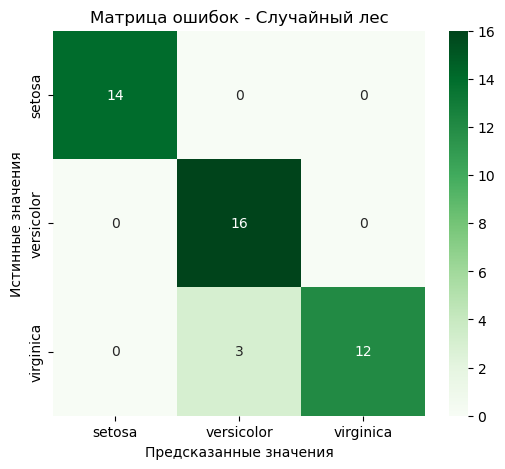

In [159]:
plt.figure(figsize=(6, 5))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['setosa', 'versicolor', 'virginica'],
            yticklabels=['setosa', 'versicolor', 'virginica'])
plt.title('Матрица ошибок - Случайный лес')
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.show()

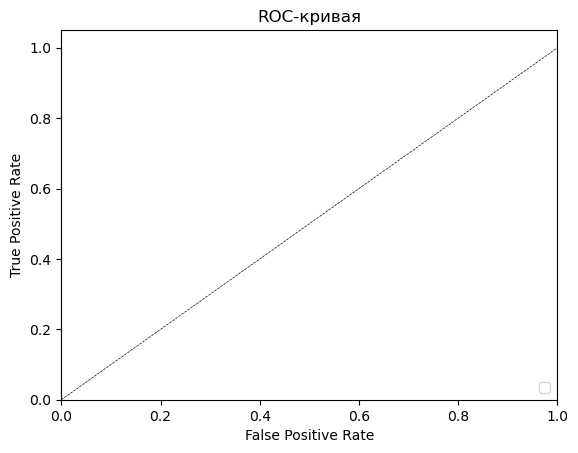

In [160]:
plt.plot([0, 1], [0, 1], 'k--', linewidth=0.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend(loc="lower right")
plt.show()

#### Вывод значений метрик

In [161]:
print(f"Accuracy:       {accuracy_rf:.4f}")
print(f"Precision:      {precision_rf:.4f}")
print(f"Recall:         {recall_rf:.4f}")
print(f"F1-score:       {f1_rf:.4f}")
print(f"ROC-AUC:        {roc_auc_rf:.4f}")

Accuracy:       0.9333
Precision:      0.9439
Recall:         0.9333
F1-score:       0.9325
ROC-AUC:        0.9971


### Вывод

Случайный лес показал наилучшие результаты. Матрица ошибок подтверждает высокое качество классификации.

## Логистическая регрессия

In [162]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [163]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [164]:
log_reg = LogisticRegression(multi_class='multinomial', random_state=19, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=19)

In [165]:
y_pred_log = log_reg.predict(X_test_scaled)
y_pred_proba_log = log_reg.predict_proba(X_test_scaled)

In [166]:
accuracy_log = accuracy_score(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log, average='weighted')
recall_log = recall_score(y_test, y_pred_log, average='weighted')
f1_log = f1_score(y_test, y_pred_log, average='weighted')
roc_auc_log = roc_auc_score(y_test, y_pred_proba_log, multi_class='ovr')

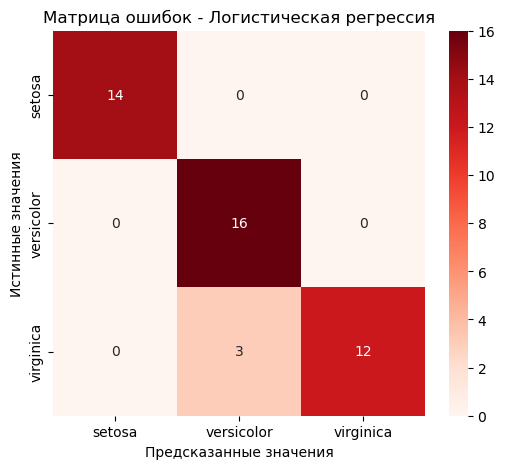

In [167]:
plt.figure(figsize=(6, 5))
cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['setosa', 'versicolor', 'virginica'],
            yticklabels=['setosa', 'versicolor', 'virginica'])
plt.title('Матрица ошибок - Логистическая регрессия')
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.show()

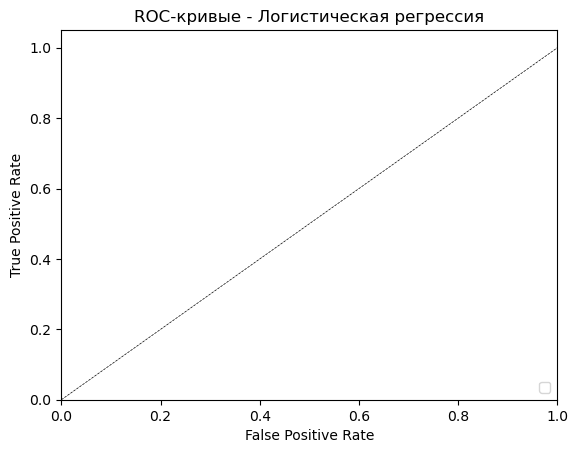

In [168]:
plt.plot([0, 1], [0, 1], 'k--', linewidth=0.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые - Логистическая регрессия')
plt.legend(loc="lower right")
plt.show()

In [169]:
print(f"Accuracy:       {accuracy_log:.4f}")
print(f"Precision:      {precision_log:.4f}")
print(f"Recall:         {recall_log:.4f}")
print(f"F1-score:       {f1_log:.4f}")
print(f"ROC-AUC:        {roc_auc_log:.4f}")

Accuracy:       0.9333
Precision:      0.9439
Recall:         0.9333
F1-score:       0.9325
ROC-AUC:        0.9971


### Вывод

Логистическая регрессия тоже показала отличные результаты, ровно такие же,
как и случайный лес.

## Вывод обучения моделей

Все модели успешно справились с задачей классификации видов ирисов. Каждая модель демонстрирует свои преимущества и может быть полезна в зависимости от конкретных требований проекта.

##### <h1 style="background:lightgreen;padding:10px;align:center;border-radius:13px;">Построение модели K-means</h1>

In [170]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score

### Выбор оптимального значения количества кластеров (гиперпараметр k)

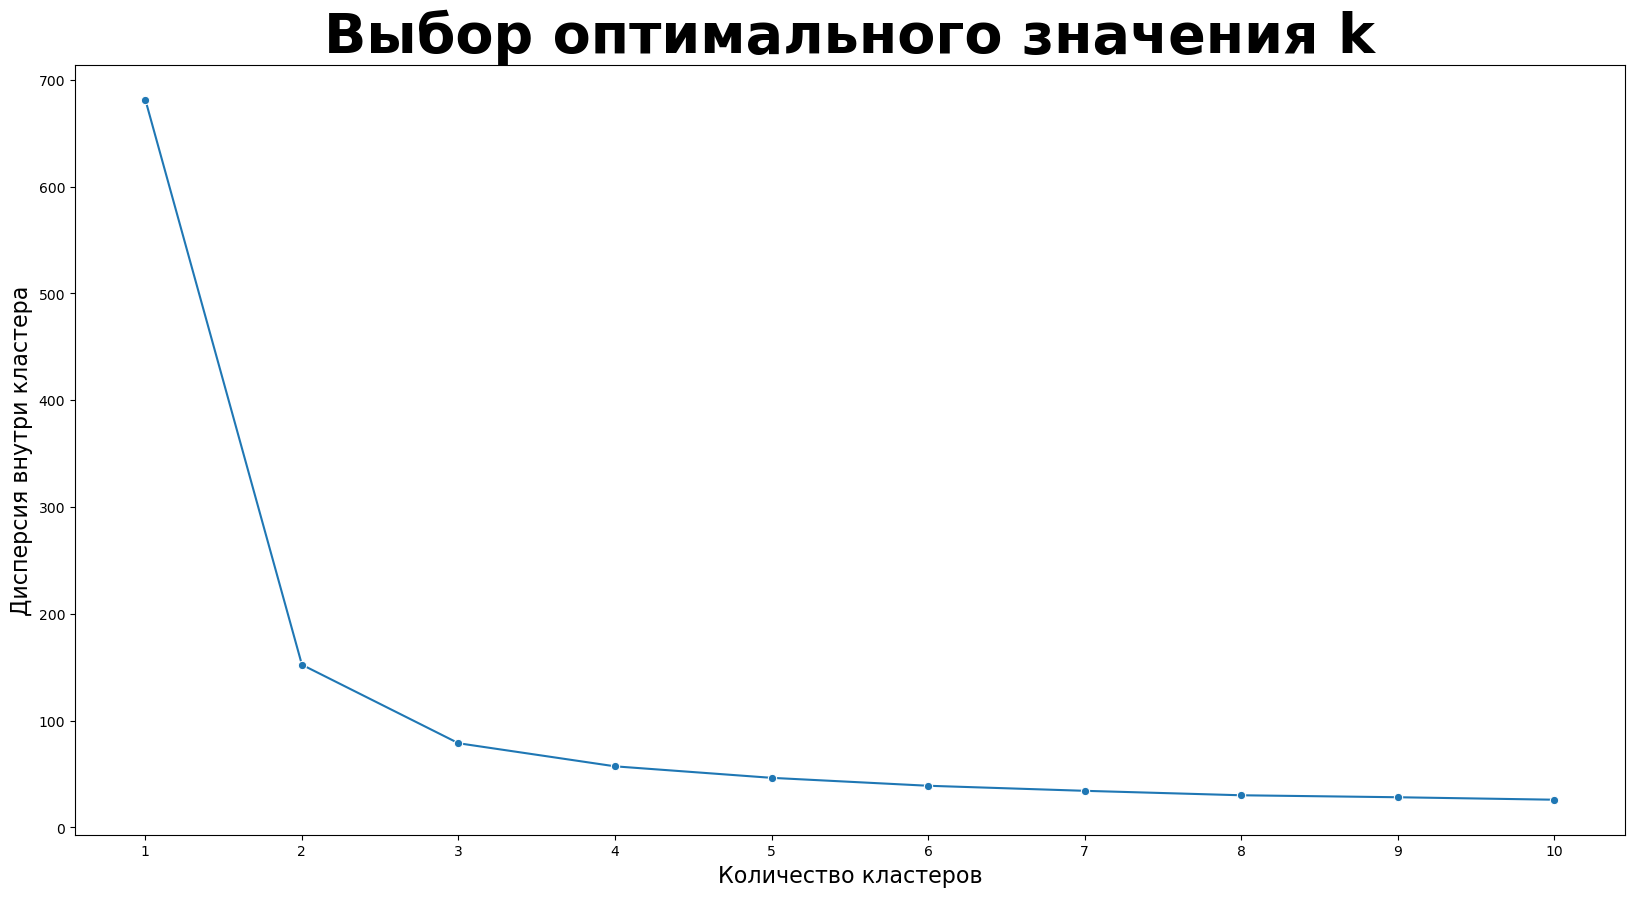

In [171]:
inertia_scores = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k,
                    n_init=10,
                    random_state=42)
    kmeans.fit(df_features)
    inertia_scores.append(kmeans.inertia_)
  
fig, ax = plt.subplots(figsize=(20, 10))
sns.lineplot(x=range(1, 11),
             y=inertia_scores,
             marker='o',)
plt.title('Выбор оптимального значения k', fontsize=40, fontweight='bold')
plt.xlabel('Количество кластеров', fontsize=16)
plt.ylabel('Дисперсия внутри кластера', fontsize=16)
plt.xticks(range(1, 11))

plt.show()

In [172]:
df_features = pd.DataFrame(iris.data, columns=iris.feature_names)
df_target = pd.DataFrame(iris.target, columns=['target'])
df_target['species'] = [iris.target_names[i] for i in iris.target]

In [173]:
kmeans = KMeans(n_clusters=3,
                n_init=10,
                algorithm='lloyd',
                random_state=42)

kmeans.fit(df_features)

KMeans(n_clusters=3, n_init=10, random_state=42)

In [174]:
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

In [175]:
labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int32)

In [176]:
silhouette = silhouette_score(df_features, labels)
chi = calinski_harabasz_score(df_features, labels)
print(f'Силуэт: {silhouette:.3f}')
print(f'Calinski-Harabasz Index: {chi:.3f}')

Силуэт: 0.553
Calinski-Harabasz Index: 561.628


In [177]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

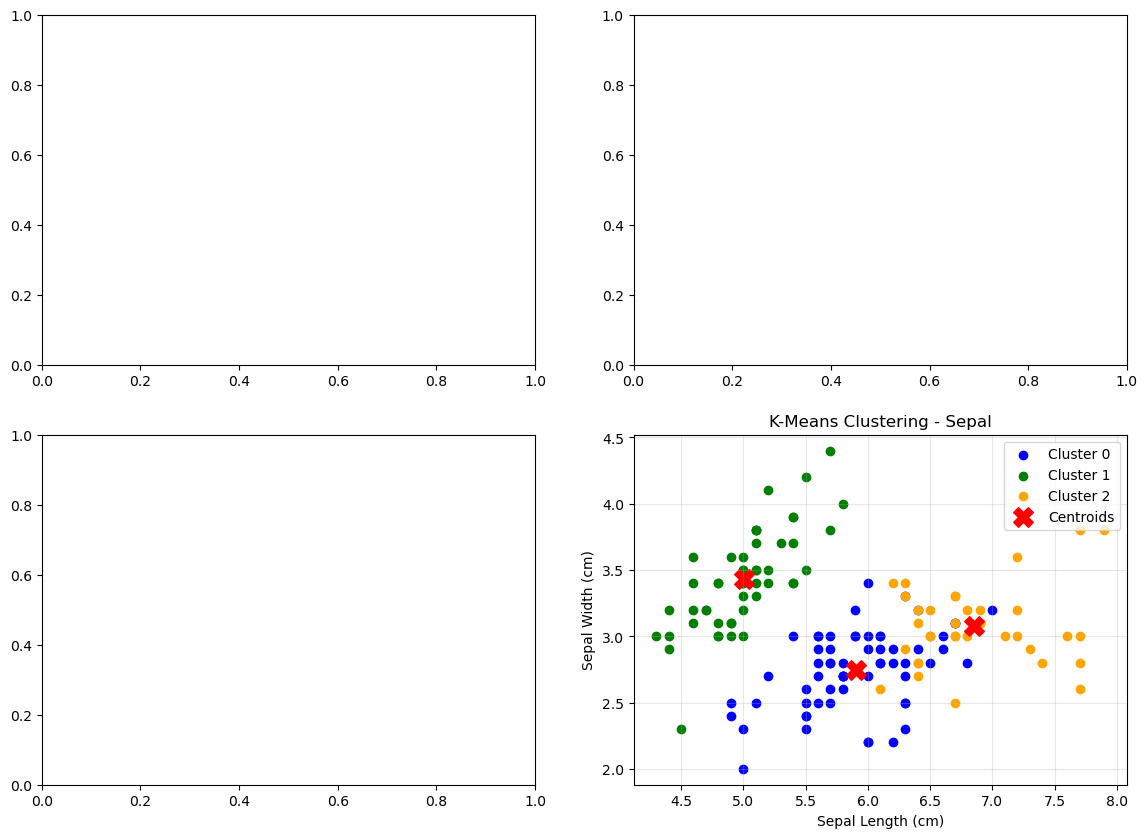

In [178]:
colors = ['blue', 'green', 'orange']
for i in range(3):
    plt.scatter(df_features.iloc[labels == i, 0],
                df_features.iloc[labels == i, 1],
                c=colors[i], label=f'Cluster {i}')

# Визуализируем центры кластеров
plt.scatter(centroids[:, 0], centroids[:, 1], 
            marker='X', s=200, color='red', label='Centroids')

plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('K-Means Clustering - Sepal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [179]:
from sklearn.decomposition import PCA

In [180]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(df_features)

principal_df = pd.DataFrame(data=principal_components,
                           columns=['PC1', 'PC2'])

centroids = kmeans.cluster_centers_
centroids_pca = pca.transform(centroids)

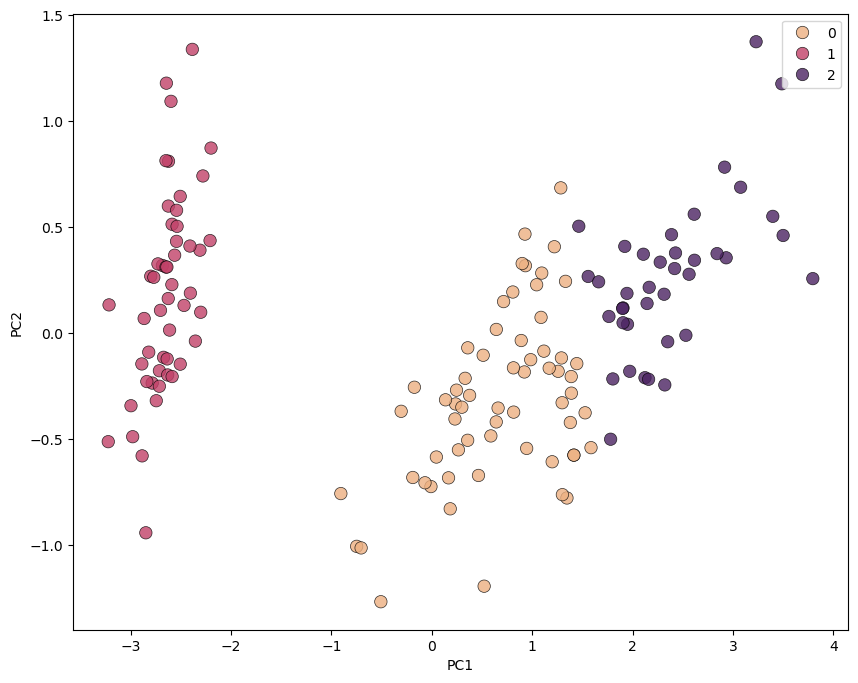

In [181]:
plt.figure(figsize=(10, 8))

# Точки данных по кластерам
sns.scatterplot(x=principal_df.iloc[:, 0], 
                y=principal_df.iloc[:, 1], 
                hue=labels,  # метки кластеров
                palette="flare", 
                s=80,
                alpha=0.8,
                edgecolor='black',
                linewidth=0.5)
plt.show()

In [182]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
import plotly.express as px

In [183]:
def PCAplot3D(x_data, y_data=None):
    components = PCA(n_components=3).fit_transform(x_data)
    fig = px.scatter_3d(x=components[:,0], y=components[:,1], z=components[:,2], 
                        color=y_data, title='PCA 3D')
    fig.update_traces(marker=dict(size=4, opacity=0.7))
    fig.show()

In [184]:
PCAplot3D(df_features)

In [185]:
PCAplot3D(df_features, y_data=kmeans.labels_)

In [186]:
PCAplot3D(df_features, y_data=df_target['species'])

##### <h1 style="background:lightgreen;padding:10px;align:center;border-radius:13px;">Agglomerative Clustering by Ward</h1>

In [187]:
import scipy.cluster.hierarchy as sch

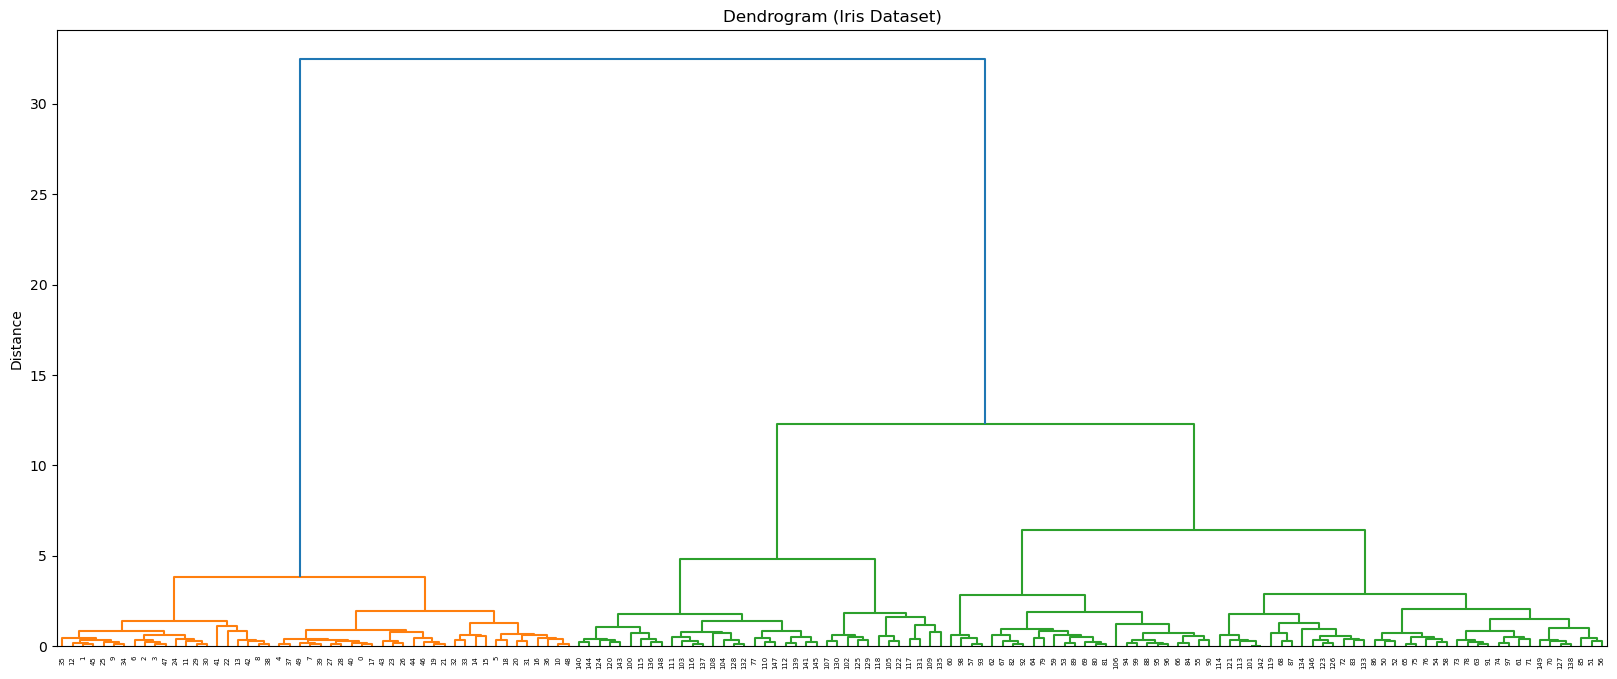

In [188]:
plt.figure(figsize=(20, 8))
dendrogram = sch.dendrogram(sch.linkage(df_features, method='ward'))
plt.title('Dendrogram (Iris Dataset)')
plt.ylabel('Distance')
plt.show()

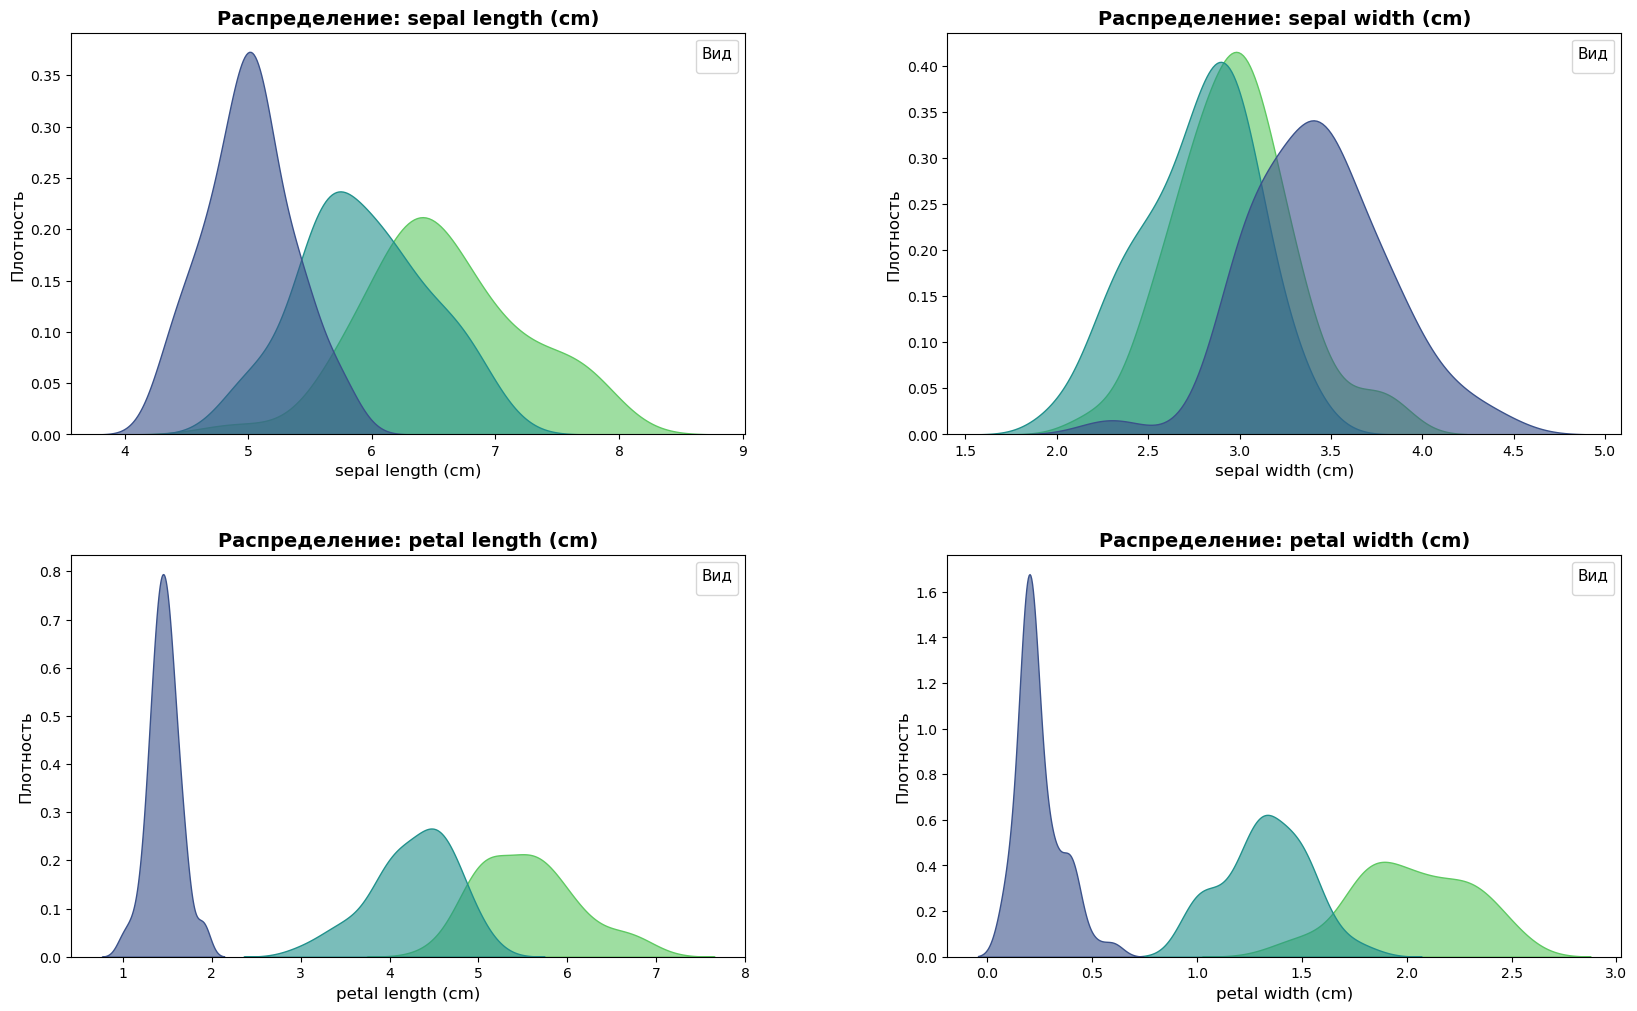

In [190]:
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

plt.subplots_adjust(hspace=0.3, wspace=0.3)

# Список признаков ирисов
columns = ['sepal length (cm)', 'sepal width (cm)', 
           'petal length (cm)', 'petal width (cm)']

for i, column in enumerate(columns):
    ax = axes[i // 2, i % 2]
    sns.kdeplot(data=df_features,
                x=column,
                fill=True,
                alpha=0.6,
                hue=df_target['species'],
                ax=ax,
                palette='viridis')
    
    ax.set_title(f'Распределение: {column}', fontweight='bold', fontsize=14)
    ax.set_xlabel(column, fontsize=12)
    ax.set_ylabel('Плотность', fontsize=12)
    ax.legend(title='Вид', fontsize=10, title_fontsize=11)

plt.show()

In [191]:
df_mean_species = df_features.copy()
df_mean_species['Species'] = df_target['species']

df_mean = df_mean_species.groupby('Species').agg({
    'sepal length (cm)': 'mean',
    'sepal width (cm)': 'mean', 
    'petal length (cm)': 'mean',
    'petal width (cm)': 'mean'
}).round(2)

df_mean.index.name = None
print("Средние значения по видам ирисов:")
print(df_mean)

Средние значения по видам ирисов:
            sepal length (cm)  sepal width (cm)  petal length (cm)  \
setosa                   5.01              3.43               1.46   
versicolor               5.94              2.77               4.26   
virginica                6.59              2.97               5.55   

            petal width (cm)  
setosa                  0.25  
versicolor              1.33  
virginica               2.03  


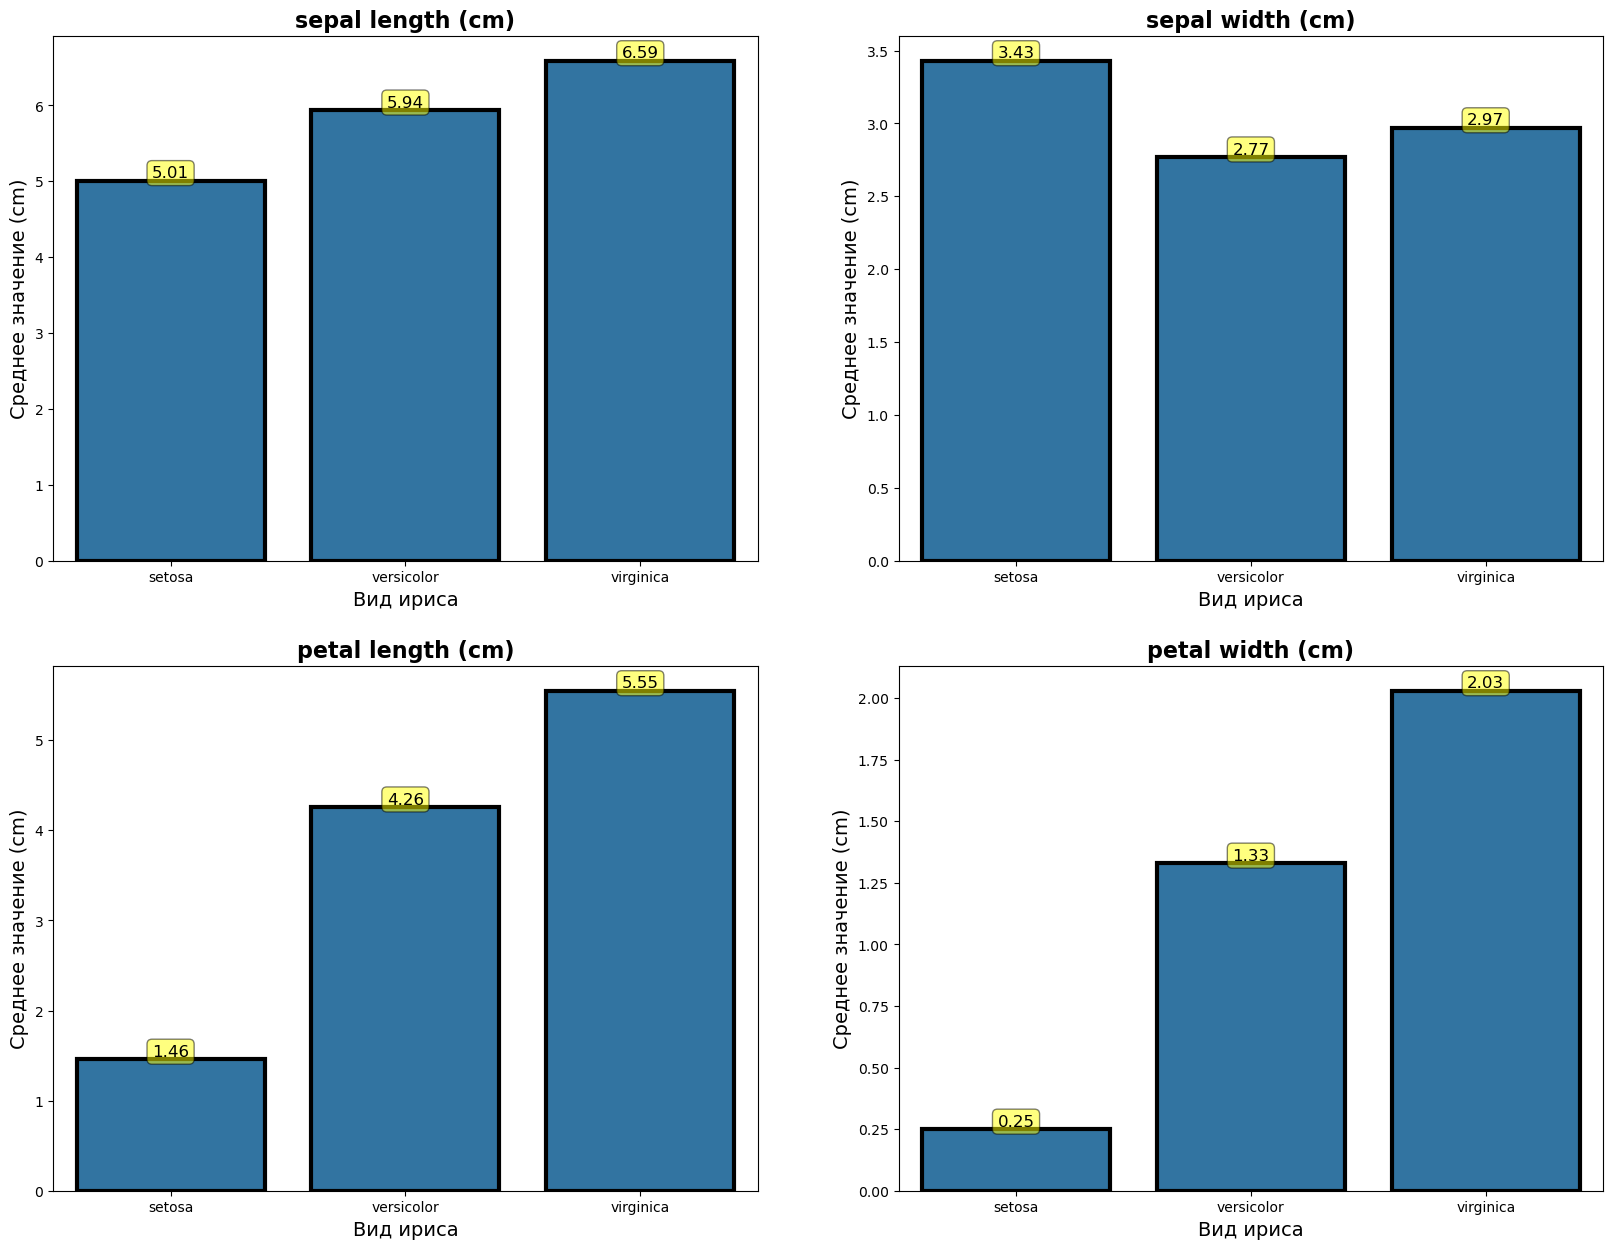

In [199]:
fig, axes = plt.subplots(2, 2, figsize=(20, 15))

columns = df_mean.columns

for i, column in enumerate(columns):
    ax = axes[i // 2, i % 2]
    p1 = sns.barplot(data=df_mean,
                     x=df_mean.index,
                     y=column,
                     linewidth=3,
                     edgecolor='black',
                     ax=ax)
    
    for container in p1.containers:
        p1.bar_label(container, bbox=bbox, fmt='%.2f', 
                    fontsize=12)
    
    ax.set_title(f'{column}', fontweight='bold', fontsize=16)
    ax.set_xlabel('Вид ириса', fontsize=14)
    ax.set_ylabel('Среднее значение (cm)', fontsize=14)

plt.show()

#### Кластер 0 (Iris-setosa):
- Маленькие цветки с короткими лепестками
- Относительно широкие чашелистики
- Компактная форма цветка

#### Кластер 1 (Iris-versicolor):
- Цветки среднего размера
- Умеренная длина и ширина лепестков
- Сбалансированные пропорции

#### Кластер 2 (Iris-virginica):

- Крупные цветки с длинными лепестками
- Узкие чашелистики
-Наиболее выраженные размеры лепестков

### Общий вывод:
Алгоритм K-Means успешно разделил ирисы на 3 кластера, которые хорошо соответствуют биологическим видам. Наиболее значимыми признаками для кластеризации оказались размеры лепестков (petal length и petal width), которые демонстрируют наибольшие различия между кластерами. Кластеры отличаются по всем четырем признакам, что свидетельствует о хорошем разделении данных.